# RideWise ---- Customer Segmentation

purpose : Group all the riders into different behavioral clusters, we can tailor retention strategies

In [28]:
## Setup & import libraries
import os, warnings
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style = "whitegrid", font_scale = 1.2)


# import our algorithm libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define the data path
DATA_PROCESSED = "data/processed"
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

features = pd.read_csv(os.path.join(DATA_PROCESSED, "features.csv"))

## Step 1- Select Clustering Features

- we need to define the features we would use for segmentation
    -1  -RFM features
    -2  -Trips Behavior
    -3  Session Engagement features
    -4  Temporal features

In [29]:
features.head()

,user_id,churned,days_since_last_trip_x,days_since_last_session,trips_last_7_days,trips_last_30_days_x,trips_last_60_days,trips_last_90_days,monetary_total_x,monetary_avg,...,account_age_days,r30,p30,activity_trend,activity_ratio,unique_active_days,was_referred,avg_rating_given,loyalty_encoded,city_encoded
0,R00000,0,25,0.0,0,1,1,3,414.13,16.57,...,93,1.0,0.0,1.0,1.00,25,1,5.0,0,0
1,R00001,1,5,0.0,1,2,3,3,195.69,13.98,...,230,2.0,1.0,1.0,2.00,13,0,4.7,0,0
2,R00002,1,14,0.0,0,1,4,5,482.94,20.12,...,232,1.0,3.0,-2.0,0.33,22,0,4.2,0,1
3,R00004,0,12,0.0,0,2,2,5,391.15,24.45,...,250,2.0,0.0,2.0,2.00,16,1,3.9,1,1
4,R00005,0,2,0.0,1,2,2,4,300.63,15.82,...,657,2.0,0.0,2.0,2.00,19,0,5.0,0,1


In [45]:
CLUSTER_COLS = [

    # RFM features
    "recency_score", "frequency_score", "monetary_score", "rfm_score_combined",

    # Trips behaviour
    "avg_fare", "avg_surge", "tip_rate", "peak_hour_rate", "weekend_ratio",

    # Session engagement 
    "sessions_last_30d", "avg_time_on_app", "session_conversion_rate", "engagement_score",

    # Temporal features
    "account_age_days", "activity_trend"
]
# K-Means Clustering cant handle missing values, so we drop 
seg_df = features[["user_id", "churned"] + CLUSTER_COLS].dropna().copy()
print (f"Riders for Segmentation: {len(seg_df)}")

Riders for Segmentation: 9204


## Step 2 - SCALING & THE ELBOW TEST

# why are we scaling 
#### example without scaling 
-RIDER A : account_age_days = 500, rfm_score = 5
-RIDER B : account_age_days = 100, rfm_score = 1

#### The problem
- Different in account age = 500-1-- = 400
- different in rfm score = 5-1 = 4
- Total distance =  = sqrt(400^2 + 4^2) = 400.02 (account age dominates the distance)

#### The problem with the huge 400 days difference dominates , recency score 1 vs 4 doesnt really matter 

#### solution  scaling
- convert each feature of that riders to mean = 0 and std = 1
- both feature from these rider can contribute equally to distance calculation

####### Example with scaling 
- RIDER A : account_age_days = 1.2, rfm_score = 1.5
- RIDER B : account_age_days = -0.8, rfm_score = -1.2

#### DISTANCE CALCULATION
# sqrt(2^2 + 2.7^2) = 3.4              (is a huge difference like 400.02)

In [31]:
scalar = StandardScaler()
X = scalar.fit_transform(seg_df[CLUSTER_COLS])

## STEP 3 - Elbow Test  + Silhoutte: Finding the right number of clustering 

- How many customers group should we create
- should k = 2 or k = 20 or 4-6

##### Inertia (sum of squares)
- measure how tightly packed each grouo/cluster is 
-the lower the cluster the better (more space)
- sum of squared distance from each point to its cluster center 
law of inertia says in every cluster there is always a center  

In [32]:
 # KMEANS CLUSTERING

inertia = []
silhouette = []
K_RANGE = range(2, 9)


# K - Number of clusters
# Means - Algorithm uses mean (average ) of data point to find clusters 
#n_init - run algorithmn 10 times with different random state (42), and picks the best
for k in K_RANGE:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X, labels, sample_size = 3000, random_state = 42))

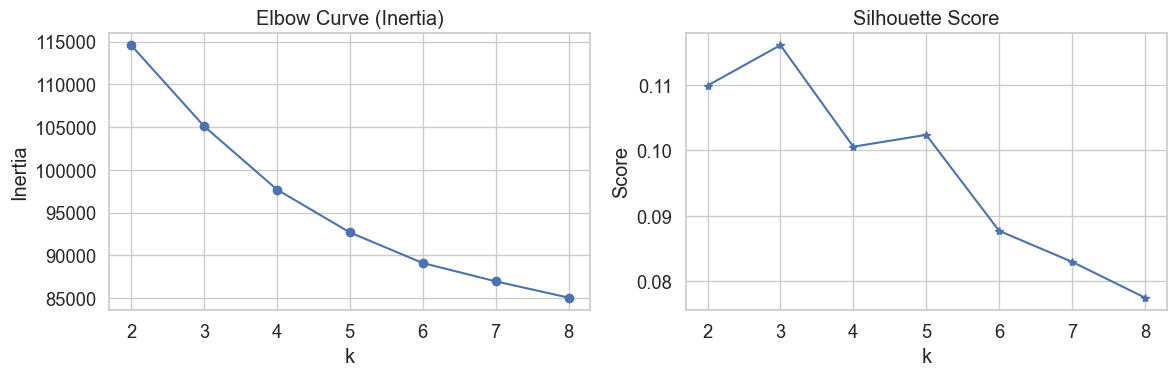

In [33]:
# silhoutter sscore 
# helps us to measure how well separated the cluster are 
# Range : -1 ---------1
# closer 1 === better (cluster are distinct, no overlap)
# closer 0 === cluster overlap

# Examples : for each rider
# a - average distance to others in same cluster ( should be small)
# b = average  distance in other cluster (should be large )



# silhoutter = (b-a)/ max (a, b)
# silhoutte score = 0.7 Great cluster are well separated 
# silhoutte = 0.3 .... some might overlap
# Silhoutte  is 0.1  cluster are poor 

fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes[0].plot(list(K_RANGE), inertia, marker = "o")
axes[0].set(title = "Elbow Curve (Inertia)", xlabel = "k", ylabel = "Inertia")

axes[1].plot(list(K_RANGE), silhouette, marker = "*")
axes[1].set(title = "Silhouette Score", xlabel = "k", ylabel = "Score")
plt.tight_layout()
plt.show()

In [34]:
# k = 2  silhoutte = 0.11
# k = 3 silhouette = 0.118
# k = 4 silhouette = 0.10-------------- k = 4 or 5
# k = 5 silhouette = 0.103
# k = 6 silhouette = 0.088
# k = 7 silhouette = 0.084
# k = 8 silhouette = 0.078--------------- too many

# Elbow you look for the sharp drop in inertia, which is at k = 4, but silhouette score is higher at k = 3.
# k 2 ----- k=3 inertia = 115k ----- 105k
# k 3 ----- k=4 inertia = 105k ----- 97k still a good drop or worth 
# k 4 ----- k=5 inertia = 97k ----- 93k flattening out

# Step 4 

In [47]:
# WHY ARE  WE CHOOSING K = 4 

#Elbow chart
# inertia drops sharply until k = 4
# after k = 4, diminishing return (line flatten)
 
# silhoutte chart
# k = 4 had a descent separation


K_FINAL = 4 
kmeans = KMeans(n_clusters = K_FINAL, random_state = 42, n_init = 10)
seg_df["cluster"] = kmeans.fit_predict(X)

final_sil = silhouette_score(X, seg_df["cluster"], sample_size = 3000, random_state = 42)
print (f"k={K_FINAL} | Inertia: {kmeans.inertia_:.0f} | Silhouette: {final_sil:.2f}")
print (seg_df["cluster"].value_counts().sort_index())

k=4 | Inertia: 97692 | Silhouette: 0.10
cluster
0    2784
1    2812
2     623
3    2985
Name: count, dtype: int64


# Step 5 - Cluster Profiling 

we have grouped rider into 4 cluster, but we dont know what makes each cluster unique......

show the average behaviour of each cluster 


In [48]:
profile_cols = [
    "rfm_score_combined","frequency_score", "monetary_score", "avg_fare", 
    "sessions_last_30d","engagement_score","activity_trend"
]

profile = seg_df.groupby("cluster")[profile_cols].mean().round(2)
print (profile.T.to_string())

cluster                  0       1        2       3
rfm_score_combined   11.38    5.65     9.34    9.86
frequency_score       3.64    1.51     3.17    3.76
monetary_score        4.19    2.61     3.06    2.25
avg_fare             16.53   15.18    15.44   14.53
sessions_last_30d     5.03    5.09     4.60    4.96
engagement_score    200.42  210.96  1134.05  203.63
activity_trend        0.45   -1.46     0.17    0.93


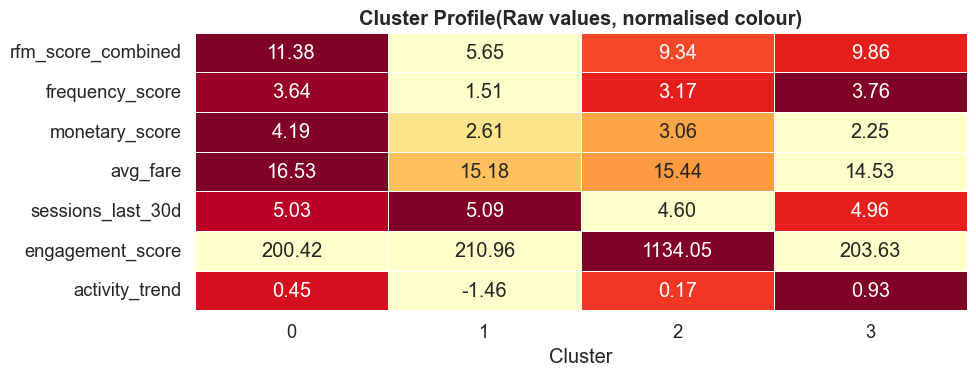

In [51]:
# cluster 0 = High RFM score ----- champions
# cluster 1 = Low RFM score ----- Dormant

# Heat map Visualisation 
# Normalisation of profile converts all the average in our profile to 0-1 


profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize = (10,4))

sns.heatmap(
    profile_norm.T, annot = profile.T, fmt = ".2f", cmap = "YlOrRd", linewidths= 0.5, ax=ax, cbar = False
)

ax.set_title("Cluster Profile(Raw values, normalised colour)",fontweight = "bold")
ax.set_xlabel("Cluster")
plt.tight_layout()
plt.show()